LAP-1 : Làm quen với PyTorch

Bai 1:

In [1]:
import torch

x = torch.tensor(2.0, requires_grad=True)

y = x**3 + 2*x**2 + 5*x + 1

y.backward()

print("y =", y.item())
print("dy/dx =", x.grad.item())

y = 27.0
dy/dx = 25.0


step  0: x = 1.7500, y = 27.0000
step  5: x = 0.9298, y = 9.6814
step 10: x = 0.4539, y = 4.3912
step 15: x = 0.1249, y = 1.9893
step 20: x = -0.1297, y = 0.5989
step 25: x = -0.3439, y = -0.3602
step 30: x = -0.5366, y = -1.1217
step 35: x = -0.7208, y = -1.8049
step 40: x = -0.9070, y = -2.4915
step 45: x = -1.1061, y = -3.2630


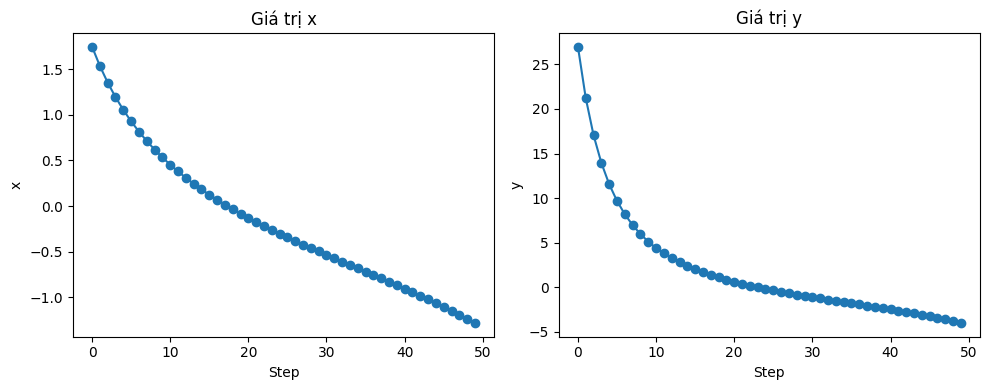

In [7]:
import torch
import matplotlib.pyplot as plt

# Khởi tạo x
x = torch.tensor(2.0, requires_grad=True)

lr = 0.01

history_x = []
history_y = []

for step in range(50):

    # Hàm số
    y = x**3 + 2*x**2 + 5*x + 1

    # Tính gradient
    y.backward()

    # Cập nhật x
    with torch.no_grad():

        x -= lr * x.grad

        # reset gradient
        x.grad.zero_()

    # Lưu lịch sử
    history_x.append(x.item())
    history_y.append(y.item())

    # In kết quả
    if step % 5 == 0:
        print(f"step {step:2d}: x = {x.item():.4f}, y = {y.item():.4f}")

# Vẽ đồ thị
plt.figure(figsize=(10,4))

# Đồ thị x
plt.subplot(1,2,1)
plt.plot(history_x, 'o-')
plt.xlabel("Step")
plt.ylabel("x")
plt.title("Giá trị x")

# Đồ thị y
plt.subplot(1,2,2)
plt.plot(history_y, 'o-')
plt.xlabel("Step")
plt.ylabel("y")
plt.title("Giá trị y")

plt.tight_layout()
plt.show()

Nhan xet: Phuong trinh vo nghiem, ham khong co cuc tieu thuc, x hoi tu ve -vo cung


Bai 2:

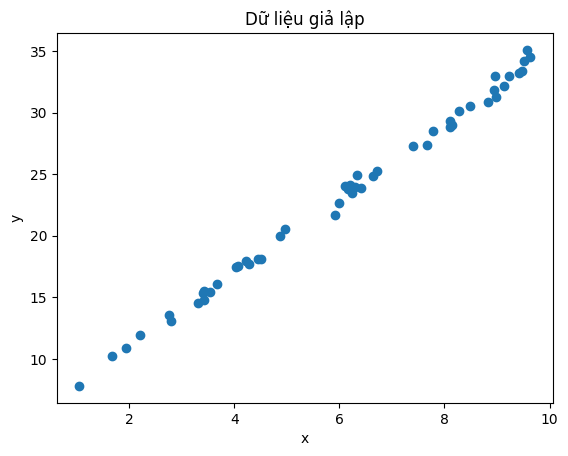

In [8]:
import torch
import matplotlib.pyplot as plt


torch.manual_seed(42)

# 50 điểm trong [1,10]
x = torch.rand(50) * 9 + 1


noise = torch.randn(50) * 0.5


y = 3*x + 5 + noise

# Vẽ dữ liệu
plt.scatter(x.numpy(), y.numpy())

plt.xlabel("x")
plt.ylabel("y")
plt.title("Dữ liệu giả lập")

plt.show()

In [9]:
# Khởi tạo w và b
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

print("w =", w.item())
print("b =", b.item())

w = 0.0
b = 0.0


In [10]:
lr = 0.01

loss_history = []

for epoch in range(200):

    # Predict
    y_pred = w*x + b

    # MSE Loss
    loss = ((y - y_pred)**2).mean()

    # Tính gradient
    loss.backward()

    # Cập nhật tham số
    with torch.no_grad():

        w -= lr * w.grad
        b -= lr * b.grad

        # reset gradient
        w.grad.zero_()
        b.grad.zero_()

    loss_history.append(loss.item())

    # In mỗi 20 vòng
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}: w={w.item():.4f}, b={b.item():.4f}, loss={loss.item():.4f}")

Epoch   0: w=3.1893, b=0.4650, loss=596.5239
Epoch  20: w=3.6115, b=0.7667, loss=2.6575
Epoch  40: w=3.5797, b=0.9909, loss=2.3999
Epoch  60: w=3.5496, b=1.2030, loss=2.1696
Epoch  80: w=3.5212, b=1.4035, loss=1.9636
Epoch 100: w=3.4942, b=1.5931, loss=1.7793
Epoch 120: w=3.4688, b=1.7725, loss=1.6145
Epoch 140: w=3.4447, b=1.9421, loss=1.4671
Epoch 160: w=3.4220, b=2.1026, loss=1.3352
Epoch 180: w=3.4004, b=2.2543, loss=1.2173


In [11]:
print("Kết quả cuối cùng:")
print("w =", w.item())
print("b =", b.item())

Kết quả cuối cùng:
w = 3.381056785583496
b = 2.3907840251922607


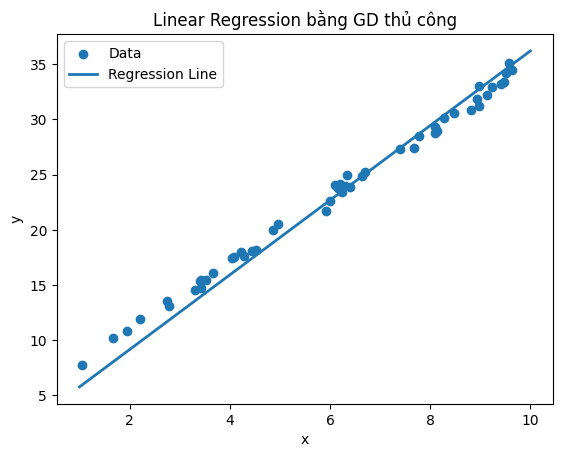

In [12]:
# Vẽ dữ liệu
plt.scatter(x.numpy(), y.numpy(), label="Data")

# Đường dự đoán
x_line = torch.linspace(1, 10, 100)

y_line = w.detach()*x_line + b.detach()

plt.plot(x_line.numpy(), y_line.numpy(), linewidth=2, label="Regression Line")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Linear Regression bằng GD thủ công")

plt.legend()

plt.show()

Nhan xet: mô hình học được khá gần slope w, nhưng b còn lệch khá nhiều

Bai 3:

In [4]:
import torch

# torch.empty
a = torch.empty(3, 4)
print("torch.empty(3,4):")
print(a)

# torch.zeros
b = torch.zeros(2, 3)
print("\ntorch.zeros(2,3):")
print(b)

# torch.ones
c = torch.ones(4)
print("\ntorch.ones(4):")
print(c)

# torch.rand
d = torch.rand(3, 3)
print("\ntorch.rand(3,3):")
print(d)

# torch.randn
e = torch.randn(3, 3)
print("\ntorch.randn(3,3):")
print(e)

torch.empty(3,4):
tensor([[6.4365e-10, 0.0000e+00, 6.6375e-10, 0.0000e+00],
        [2.2421e-44, 0.0000e+00, 1.1210e-44, 0.0000e+00],
        [6.7262e-44, 0.0000e+00, 6.7262e-44, 0.0000e+00]])

torch.zeros(2,3):
tensor([[0., 0., 0.],
        [0., 0., 0.]])

torch.ones(4):
tensor([1., 1., 1., 1.])

torch.rand(3,3):
tensor([[0.5240, 0.9266, 0.7911],
        [0.0428, 0.3631, 0.7869],
        [0.5390, 0.9509, 0.7155]])

torch.randn(3,3):
tensor([[-0.0399,  0.8199, -0.5578],
        [ 0.0611, -0.4675, -1.2206],
        [ 0.6925,  2.0093,  0.2072]])


In [5]:
import torch

# Tensor shape (2,6)
t = torch.arange(12).view(2, 6)

print("Tensor ban đầu:")
print(t)
print("Shape:", t.shape)

# Dùng view
v1 = t.view(3, 4)

print("\nSau view(3,4):")
print(v1)
print("Shape:", v1.shape)

# Tensor mẫu shape (3,4)
sample = torch.empty(3, 4)

# Dùng view_as
v2 = t.view_as(sample)

print("\nSau view_as(sample):")
print(v2)
print("Shape:", v2.shape)

Tensor ban đầu:
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])
Shape: torch.Size([2, 6])

Sau view(3,4):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Shape: torch.Size([3, 4])

Sau view_as(sample):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Shape: torch.Size([3, 4])


Bai 4:

In [13]:
import torch

# Khởi tạo biến
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

# Hàm số
f = x**2 + 2*y**2 + 3*x*y + x + y

# Tính gradient
f.backward()

print("df/dx =", x.grad.item())
print("df/dy =", y.grad.item())

df/dx = 9.0
df/dy = 12.0


step  0: x = 0.5500, y = 1.4000
step  1: x = 0.2350, y = 0.9875
step  2: x = 0.0134, y = 0.7047
step  3: x = -0.1437, y = 0.5118
step  4: x = -0.2561, y = 0.3810
step  5: x = -0.3376, y = 0.2932
step  6: x = -0.3978, y = 0.2352
step  7: x = -0.4433, y = 0.1978
step  8: x = -0.4787, y = 0.1748
step  9: x = -0.5070, y = 0.1616
step 10: x = -0.5306, y = 0.1553
step 11: x = -0.5508, y = 0.1539
step 12: x = -0.5688, y = 0.1557
step 13: x = -0.5853, y = 0.1599
step 14: x = -0.6007, y = 0.1657
step 15: x = -0.6155, y = 0.1727
step 16: x = -0.6299, y = 0.1805
step 17: x = -0.6440, y = 0.1889
step 18: x = -0.6579, y = 0.1977
step 19: x = -0.6717, y = 0.2068
step 20: x = -0.6856, y = 0.2162
step 21: x = -0.6995, y = 0.2258
step 22: x = -0.7134, y = 0.2356
step 23: x = -0.7274, y = 0.2455
step 24: x = -0.7415, y = 0.2555
step 25: x = -0.7556, y = 0.2656
step 26: x = -0.7699, y = 0.2758
step 27: x = -0.7843, y = 0.2862
step 28: x = -0.7988, y = 0.2966
step 29: x = -0.8134, y = 0.3071


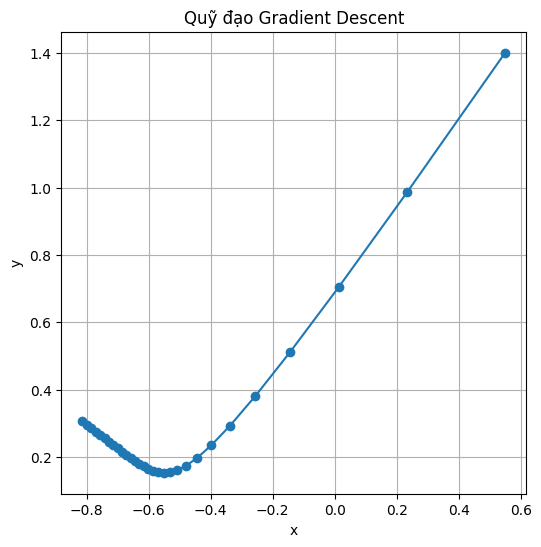

In [15]:
import torch
import matplotlib.pyplot as plt

# Khởi tạo x và y
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

lr = 0.05

# Lưu quỹ đạo
x_history = []
y_history = []

for step in range(30):

    # Hàm số
    f = x**2 + 2*y**2 + 3*x*y + x + y

    # Tính gradient
    f.backward()

    # Cập nhật Gradient Descent
    with torch.no_grad():

        x -= lr * x.grad
        y -= lr * y.grad

        # Xóa gradient cũ
        x.grad.zero_()
        y.grad.zero_()

    # Lưu lại giá trị
    x_history.append(x.item())
    y_history.append(y.item())

    # In kết quả
    print(f"step {step:2d}: x = {x.item():.4f}, y = {y.item():.4f}")

# Vẽ quỹ đạo (x,y)
plt.figure(figsize=(6,6))

plt.plot(x_history, y_history, 'o-')

plt.xlabel("x")
plt.ylabel("y")

plt.title("Quỹ đạo Gradient Descent")

plt.grid(True)

plt.show()